### Projet_02: ***AED approfondie et Visualisation des donnees***
Ici il va s'agir principalement de:
* Proceder a une mini-inspection du jeu de donnees pour voir la structure
* Proceder au nettoyage des donnees pour les preparer a l'analyse
* Enfin visualiser les donnees en fonction des metriques pertinentes

In [2]:
# Chargement des bibliotheques 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

In [ ]:
# Installation et importation du pacquage seaborn
%pip install seaborn
import seaborn as sns

In [114]:
# Chargement du jeu des donnees
df=pd.read_csv('ag_motos_tricycles.csv')

In [23]:
# Afficher l'option info() pour avoir une idee des donnees
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

* La fonction info() nous revele que le jeu de donnees a 22 699 lignes pour 18 colones. il n'existe pas de valeurs nulles.

In [97]:
df[['trip_distance','total_amount']].head(10)

,trip_distance,total_amount
0,3.34,16.56
1,1.80,20.80
2,1.00,8.75
3,3.70,27.69
4,4.37,17.80
5,2.30,12.36
6,12.83,59.16
7,2.98,19.58
8,1.20,9.80
9,1.60,16.55


In [21]:
# Verification pour les valeurs manquantes et les doublons
print(df.isnull().sum())
print(df.duplicated().sum())

Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64
0


* Avec les deux fonctions `isnull()` et `duplicated()`, on observe qu'il n'existe pas de doublons ni de valeurs nulles.

***Dans la mesure que l'on a defini `trip_distance` et `total_amount` comme des variables pertinentes pour un modele futur, nous allons davantage approfondir l'exploration des donnees: les visualisations pour voir la presence des valeurs aberrantes dans ce deux variables***

****Utiliser un diagramme à barres, un diagramme en boîte et un nuage de points sera très utile pour comprendre ces données:****
* ***Un diagramme en boîte permettra d'identifier les valeurs aberrantes et de localiser la majorité des points de données concernant la distance parcourue, la durée et le montant total;***
* ***Un nuage de points permettra de visualiser les tendances, les schémas et les valeurs aberrantes des variables clés, telles que la distance parcourue et le montant total;***
* ***Un diagramme à barres permettra de déterminer le nombre moyen de trajets par mois, par jour de semaine, par week-end, etc.***

#### 1. Premiere variable pertinente: `trip_distance`

##### 1.1 Diagramme en boites (boxplot)

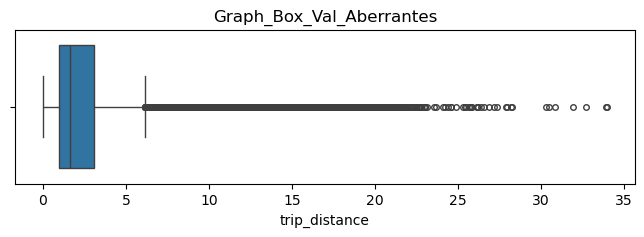

In [154]:
plt.figure(figsize=(8,2))
plt.title('Graph_Box_Val_Aberrantes')
sns.boxplot(x=df['trip_distance'], fliersize = 4)
plt.show()

In [105]:
df[['trip_distance', 'total_amount']].describe()

,trip_distance,total_amount
count,22699.000000,22699.000000
mean,2.913313,16.310502
std,3.653171,16.097295
min,0.000000,-120.300000
25%,0.990000,8.750000
50%,1.610000,11.800000
75%,3.060000,17.800000
max,33.960000,1200.290000


In [133]:
# Verifions des quantiles
quant1=df['trip_distance'].quantile(0.25)
quant3=df['trip_distance'].quantile(0.75)
IQR = quant3-quant1
born_inf=quant1-1.5*IQR
born_sup=quant3+1.5*IQR
val_aberr=df[(df['trip_distance']<born_inf)|(df['trip_distance']>born_sup)]
perc_aberr = len(val_aberr)/len(df)*100
print('Le nombre de valeurs aberrantes est de:', len(val_aberr))
print(f'Soit envirron {perc_aberr:.2f} % du jeu des donnees')

Le nombre de valeurs aberrantes est de: 2527
Soit envirron 11.13 % du jeu des donnees


**L'on constate d'apres les calculs python le dataset contient 2 527 valeurs aberrantes soit 11,13%**

##### 1.2 Histogramme

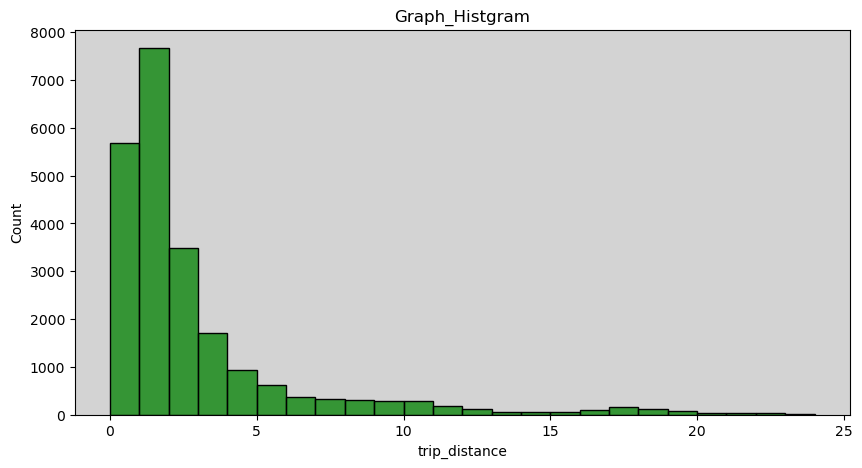

In [153]:
plt.figure(figsize=(10,5))
fig=sns.histplot(df['trip_distance'], bins=range(0,25,1), color='green')
fig.set_facecolor('lightgrey')
plt.title('Graph_Histgram')
plt.show()

* Remarque: ***La majorité des trajets sont inférieurs à deux miles. Et Le nombre de trajets diminue fortement lorsque la distance parcourue dépasse deux miles.***

#### 2. Deuxieme variable pertinente: `total_amount`

##### 2.1: Diagramme en boites (Boxplot)

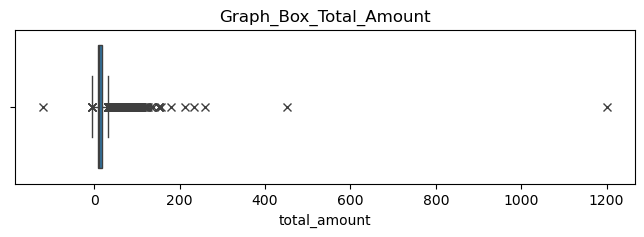

In [152]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['total_amount'], 
            fliersize=6, 
            flierprops=dict(marker='x', color= 'red'))
plt.title('Graph_Box_Total_Amount')
plt.show()

In [131]:
# Calcul des quantiles et des valeurs aberrantes `total_amount`
quant1=df['total_amount'].quantile(0.25)
quant3=df['total_amount'].quantile(0.75)
IQR = quant3-quant1
born_inf=quant1-1.5*IQR
born_sup=quant3+1.5*IQR
val_aberr=df[(df['total_amount']<born_inf)|(df['total_amount']>born_sup)]
perc_aberr = len(val_aberr)/len(df)*100
print('Le nombre de valeurs aberrantes est de:', len(val_aberr))
print(f'Soit envirron {perc_aberr:.2f} % du jeu des donnees')

Le nombre de valeurs aberrantes est de: 2161
Soit envirron 9.52 % du jeu des donnees


**L'on constate d'apres les calculs python le dataset contient 2 161 valeurs aberrantes soit 9,52%**

#### 2.2 Histogramme

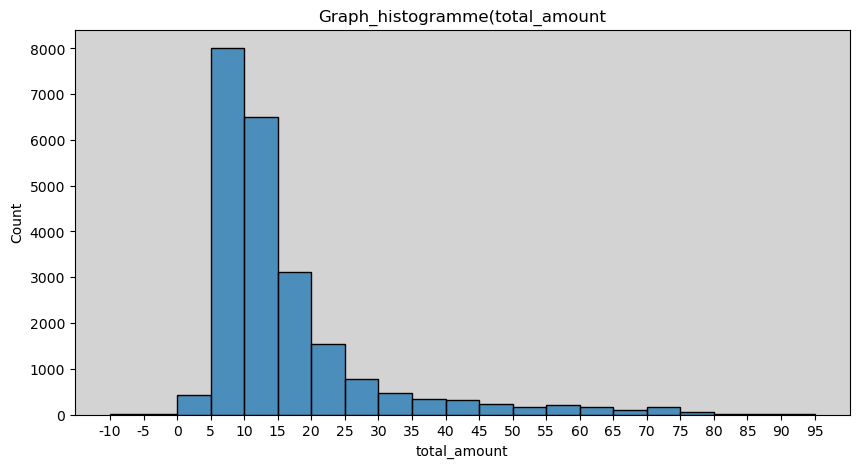

In [151]:
plt.figure(figsize=(10,5))
fig=sns.histplot(df['total_amount'], bins=range(-10, 100, 5))
fig.set_facecolor('lightgrey')
fig.set_xticks(range(-10,100,5))
fig.set_xticklabels(range(-10,100,5))
plt.title('Graph_histogramme(total_amount')
plt.show()

*****Remarque: La distribution du coût total de chaque voyage est également asymétrique à droite, la plupart des coûts se situant dans la fourchette de 5 à 15 dollars. 
A partir de 20 dollars le nombre de trajets chute fortement. Cela veut dire qu'il exite trop de petite valeurs d'une part et d'autre, la moyenne est superieure à la médiane. On peut le verifier par un code python.*****

In [142]:
# Calcul de la moyenne et de de la mediane
moyenne=df['total_amount'].mean().round(2)
mediane=df['total_amount'].median().round(2)
print('La moyenne est de:', moyenne)
print('La mediane est de:', mediane)

La moyenne est de: 16.31
La mediane est de: 11.8


* #### Donc on voit que la moyenne est superieure à la mediane.

#### **3. Examination d'autres variables: `tip_amount` et les relations eventuelles**

##### 3.1: Diagramme en boites pour la variable `tip_amount`

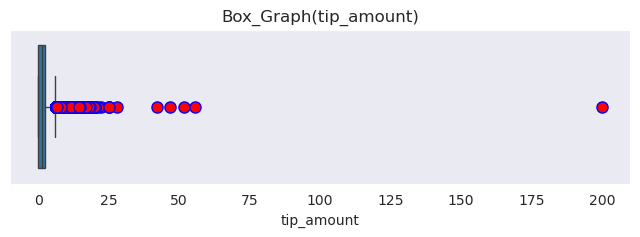

In [162]:
plt.figure(figsize = (8,2))
sns.boxplot(x=df['tip_amount'],
           fliersize = 8,
           flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='blue', markersize = 8))
sns.set_style('ticks')
plt.title('Box_Graph(tip_amount)')
plt.show()

##### 3.2: Histogramme pour la variable `tip_amount`

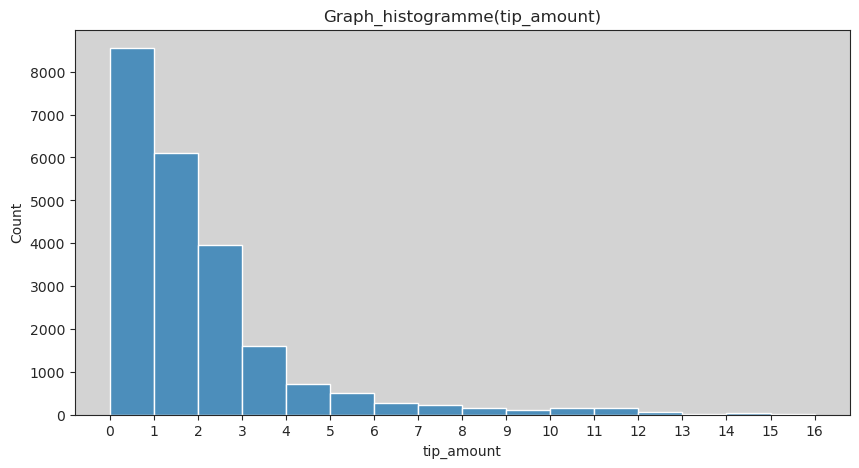

In [168]:
plt.figure(figsize=(10,5))
fig=sns.histplot(df['tip_amount'], bins=range(0, 17,1))
fig.set_facecolor('lightgrey')
fig.set_xticks(range(0,17,1))
fig.set_xticklabels(range(0,17,1))
plt.title('Graph_histogramme(tip_amount)')
plt.show()

###### *****Remarque: La distribution des pourboires est asymétrique à droite, la quasi-totalité des pourboires se situant dans la fourchette de 0 à 3 $.*****

##### **Relation entre tip_amount et Vendor**
* Tracer un histgramme empilee pour voir la contribution de chaque vendeur au montant des pourboires

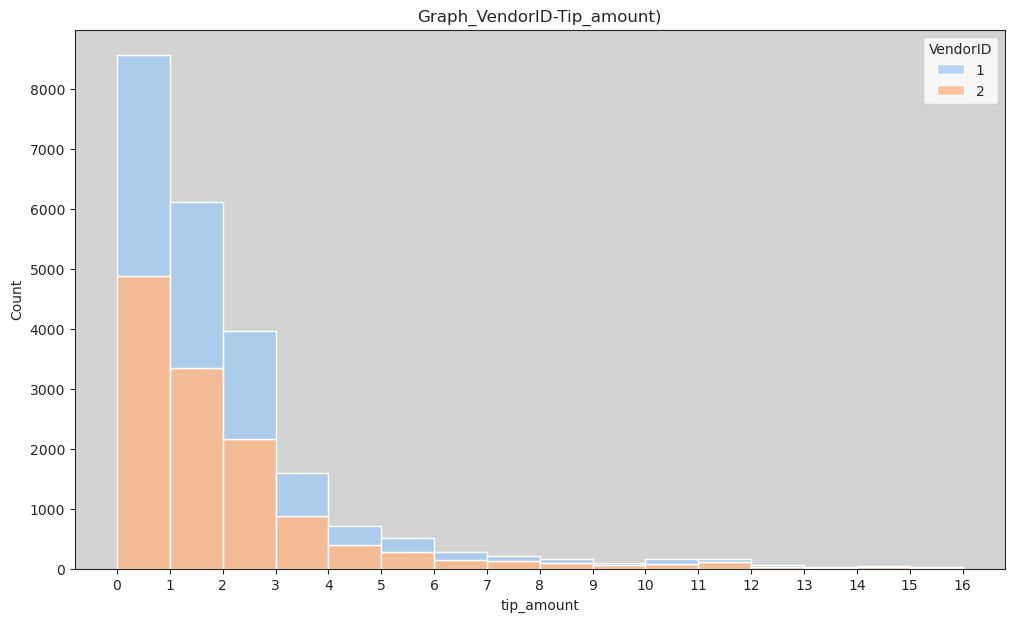

In [172]:
plt.figure(figsize=(12,7))
fig = sns.histplot(data=df, x='tip_amount', bins =range(0,17,1),
                  hue='VendorID',
                  palette='pastel',
                  multiple='stack')          # Distingue par des couleurs distinctes la variable VendorID
fig.set_facecolor('lightgrey')
fig.set_xticks(range(0,17,1))
fig.set_xticklabels(range(0,17,1))
plt.title('Graph_VendorID-Tip_amount)')
plt.show()

* Remarque : L’analyse des pourboires par vendeur révèle qu’il n’existe aucune différence notable dans leur répartition entre les deux vendeurs de l’ensemble de données. Le vendeur n° 2 effectue une part légèrement supérieure des courses, et cette proportion se maintient approximativement quel que soit le montant des pourboires.

Ensuite, examinons de plus près les pourboires les plus élevés afin de vérifier si le vendeur n° 1 reçoit sensiblement plus de pourboires généreux.

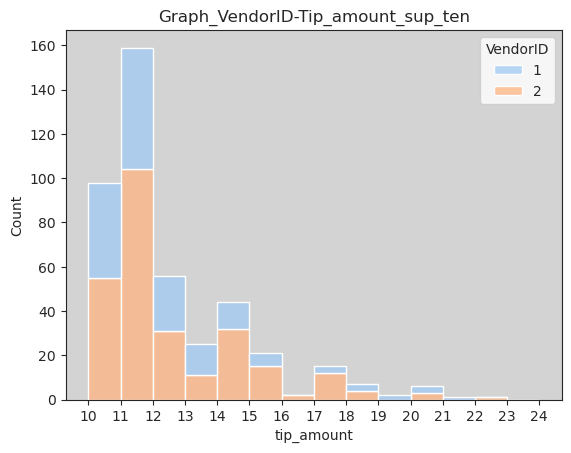

In [175]:
# Histogramme pour des pourboires > 10 $. Pour ce faire l'on peut trier df pour les tip_mount >10 et assigner une variable 
prb_ten=df[df['tip_amount']>10]
fig = sns.histplot(data=prb_ten, x='tip_amount', bins =range(10,25,1),
                  hue='VendorID',
                  palette='pastel',
                  multiple='stack')          # Distingue par des couleurs distinctes la variable VendorID
fig.set_facecolor('lightgrey')
fig.set_xticks(range(10,25,1))
fig.set_xticklabels(range(10,25,1))
plt.title('Graph_VendorID-Tip_amount_sup_ten')
plt.show()


**Remarque:** Les proportions sont maintenues même pour ces montants de pourboire plus élevés, à l’exception de l’extrémité la plus élevée, mais cela n’est pas notable en raison de la petite taille de l’échantillon pour ces montants de pourboire.

##### **Evaluation de la moyenne des pourboires (`tip_amount`) pour chaque passager**
Affiche le nombre de passager par categorie

In [180]:
df[['passenger_count']].value_counts()

passenger_count
1                  16117
2                   3305
5                   1143
3                    953
6                    693
4                    455
0                     33
Name: count, dtype: int64

**Explications:** Près des deux tiers des trajets sont individuels(*un seul passager*), même si près de 700 (*exactement 693*) trajets comptent jusqu’à six passagers. Par ailleurs, 33 trajets affichent un taux d’occupation nul(*aucun passager?*), ce qui est incohérent. Ces derniers seront probablement supprimés, sauf si une explication raisonnable est fournie.

In [191]:
# Calcul de la moyenne des pourboires par categorie de passager. C'est a dire la moyenne pour un trajet avec 1, 2, 3, etc... passagers
# Il faut garder a l'esprit que les trajets sont effectues soit avec 1 ou 2 ou 3 ou...ou 6 passagers.
moy_prb_pssgr=df.groupby(['passenger_count'])[['tip_amount']].mean().round(2)
moy_prb_pssgr

,tip_amount
passenger_count,
0,2.14
1,1.85
2,1.86
3,1.72
4,1.53
5,1.87
6,1.72


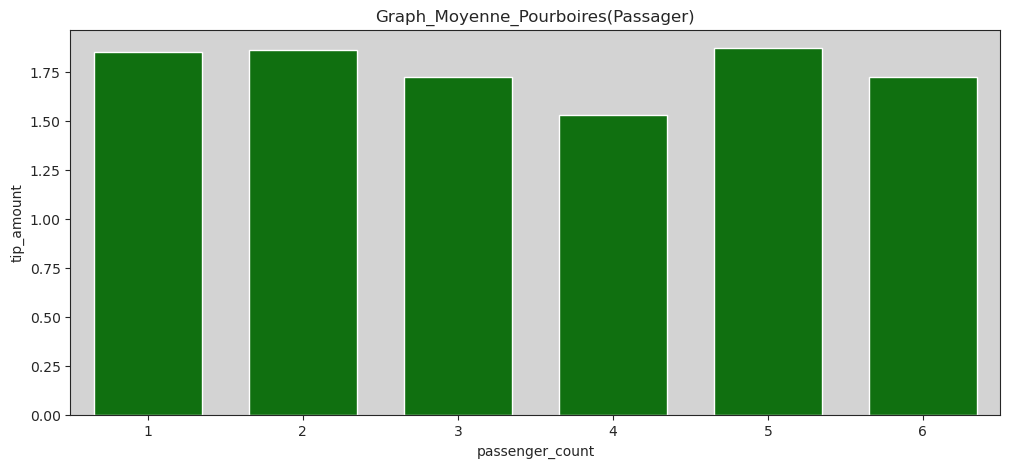

In [205]:
# Tracer un diagramme en barre pour representer cette moyenne
data=moy_prb_pssgr.tail(-1)    # Affiche les donnees 'moy_prb_pssgr' sauf la ligne 1 car elle correspond au nombre de trajets avec 0 passager
plt.figure(figsize=(12,5))
fig=sns.barplot(x=data.index,
           y=data['tip_amount'], color='green', errorbar=('ci',95), width=0.7)
fig.set_facecolor('lightgrey')
plt.title('Graph_Moyenne_Pourboires(Passager)')
plt.show()


**Remarque:** Il n'y pas une grande variation entre le monontant moyen des pourboires et le nombre de passagers. Bien qu’il diminue sensiblement pour les trajets à quatre passagers, une plus grande fluctuation est attendue, car les trajets à quatre passagers étaient les moins nombreux dans l’ensemble de données (mis à part les trajets sans passager).

In [206]:
# Affichage des noms des colonnes avec info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

#### 4. Un coup d'oeil sur les variables `tpep_picup_datetime`et `tpep_dropoff_datetime`
Ces deux variables de nature `date` sont ici au format `objectif`. 
Donc une conversion est necessaire.

#### 4.1 : le nombre de trajets par mois

In [207]:
# Conversion des variables au format `date` avec la fonction to_datetime()
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'])

In [208]:
# Creation dans le dataset de deux variables 'month' et 'day' a partir de la variable 'tpep_pickup_datetime'
df['month']=df['tpep_pickup_datetime'].dt.month_name()
df['day']=df['tpep_pickup_datetime'].dt.day_name()

In [235]:
# L'on peut calculer le nombre total de trajets pour chaque mois
traj_mois=df['month'].value_counts()
traj_mois

month
March        2049
October      2027
April        2019
May          2013
January      1997
June         1964
December     1863
November     1843
February     1769
September    1734
August       1724
July         1697
Name: count, dtype: int64

In [236]:
# Mettre les mois en ordre chronologique
ordre_mois=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
traj_mois=traj_mois.reindex(ordre_mois)
traj_mois

month
January      1997
February     1769
March        2049
April        2019
May          2013
June         1964
July         1697
August       1724
September    1734
October      2027
November     1843
December     1863
Name: count, dtype: int64

In [238]:
traj_mois.index

Index(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype='object', name='month')

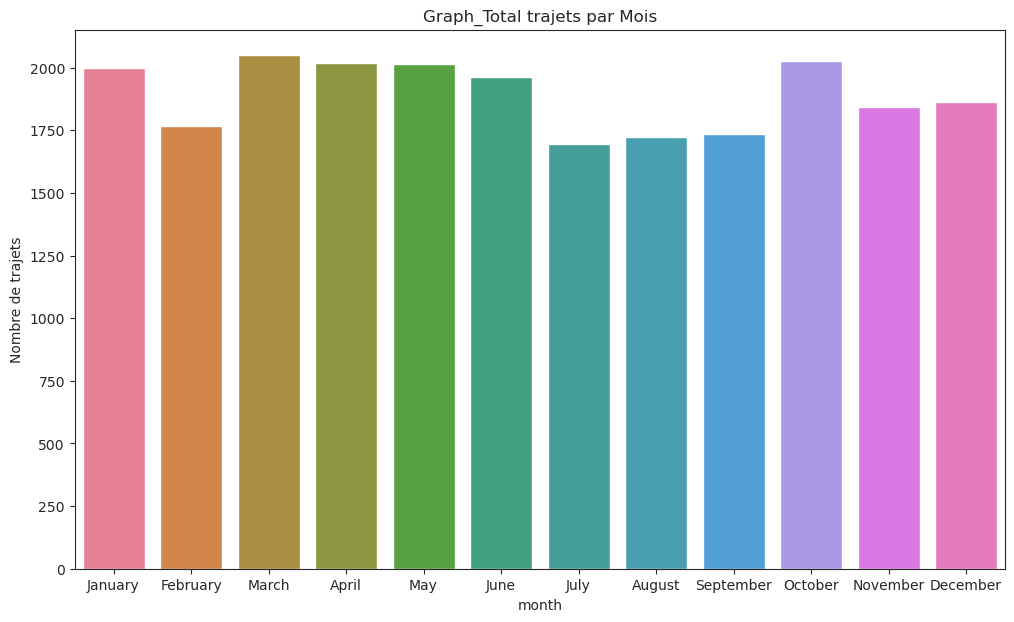

In [254]:
# L'on peut tracer un diagramme a barre pour montrer le total de trajets par mois
plt.figure(figsize=(12,7))
fig=sns.barplot(x=traj_mois.index,
               y=traj_mois.values,
                hue=traj_mois.index,
               palette = 'husl',
               legend=False
               )
fig.set_title('Graph_Total trajets par Mois')
fig.set_ylabel('Nombre de trajets')
plt.show()

**Remarque:** Les trajets mensuels sont assez constants, avec des baisses notables pendant les mois d’été de juillet, août et septembre, ainsi qu’en février.

#### 4.2 :  Le nombre de trajets par jour

In [256]:
# Total de trajets par jour 'day'
traj_jour=df['day'].value_counts()
traj_jour

day
Friday       3413
Thursday     3402
Wednesday    3390
Saturday     3367
Tuesday      3198
Sunday       2998
Monday       2931
Name: count, dtype: int64

In [257]:
# Mise en ordre des jours
ordre_jour=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traj_jour=traj_jour.reindex(ordre_jour)
traj_jour

day
Monday       2931
Tuesday      3198
Wednesday    3390
Thursday     3402
Friday       3413
Saturday     3367
Sunday       2998
Name: count, dtype: int64

In [258]:
traj_jour.index

Index(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'],
      dtype='object', name='day')

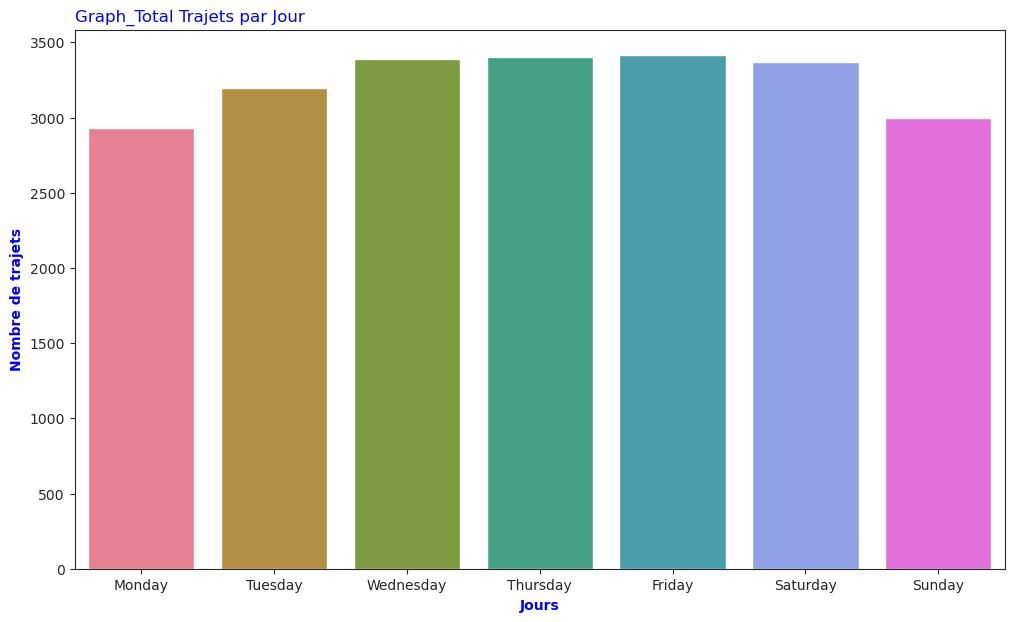

In [265]:
# Graph a barre: Nombre de trajets par jour
plt.figure(figsize=(12,7))
fig=sns.barplot(x=traj_jour.index,
               y=traj_jour.values,
               hue=traj_jour.index,
               palette='husl',
               legend=False
               )
fig.set_title('Graph_Total Trajets par Jour', loc='left', color='blue')
fig.set_ylabel('Nombre de trajets', fontweight='bold', color='blue')
fig.set_xlabel('Jours', fontweight='bold', color='blue')
plt.show()

**Remarque :** Étonnamment, le nombre de trajets quotidiens a été le plus élevé du mercredi au samedi, tandis qu’il a été le plus faible le dimanche et le lundi.

#### 4.3 : Montant Total par jour

In [270]:
montant_jour=df.groupby('day')[['total_amount']].sum()
montant_jour

,total_amount
day,
Friday,55818.74
Monday,49574.37
Saturday,51195.40
Sunday,48624.06
Thursday,57181.91
Tuesday,52527.14
Wednesday,55310.47


In [271]:
# Mise en ordre des jours
montant_jour=montant_jour.reindex(ordre_jour)
montant_jour

,total_amount
day,
Monday,49574.37
Tuesday,52527.14
Wednesday,55310.47
Thursday,57181.91
Friday,55818.74
Saturday,51195.40
Sunday,48624.06


In [272]:
montant_jour.index

Index(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'],
      dtype='object', name='day')

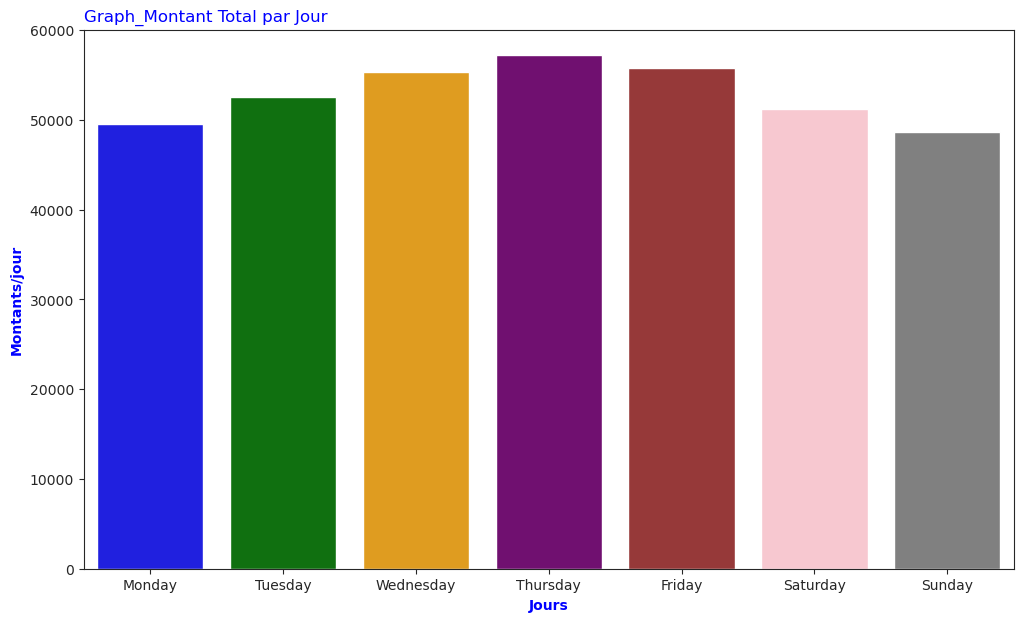

In [278]:
# Graph a barre: Montant total par jour
colors = [
"blue","green","orange","purple","brown",
"pink","gray"]
plt.figure(figsize=(12,7))
fig=sns.barplot(x=montant_jour.index,
               y=montant_jour['total_amount'],
               hue=montant_jour.index,
               palette=colors,
               legend=False)  
fig.set_title('Graph_Montant Total par Jour', loc='left', color='blue')
fig.set_ylabel('Montants/jour', fontweight='bold', color='blue')
fig.set_xlabel('Jours', fontweight='bold', color='blue')
plt.show()

**Obseravations :** jeudi a enregistré le chiffre d'affaires brut le plus élevé, tandis que dimanche et lundi ont affiché les plus faibles.
Fait intéressant: bien que samedi n'ait comptabilisé que 35 trajets de moins que jeudi, son chiffre d'affaires brut est inférieur d'environ 6 000 $ à celui de jeudi, soit une baisse de plus de 10 %.

**Conclusuions :** Cette pratique de l'AED (lanalyse exploratoire des données) est extremement importante vue qu'elle aide le professionnel des données à mieux connaître ses données, à identifier les valeurs aberrantes, à corriger les valeurs manquantes et à les préparer pour une eventuelle modélisation.

Les visualisations ont permis de comprendre par ailleurs que cet ensemble de données comporte des `valeurs aberrantes` sur lesquelles une decision doit etre prise avant de penser pour concevoir un modèle.